# 📰 Fake News Detection using Machine Learning

This project detects whether a news article is real or fake using Natural Language Processing (NLP) and Machine Learning.

Dataset: Fake and Real News Dataset from Kaggle
- Fake.csv
- True.csv

Steps:
1. Data Loading
2. Text Cleaning
3. TF-IDF Vectorization
4. Model Training (Logistic Regression)
5. Evaluation
6. Prediction

In [1]:
import numpy as np
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
import pandas as pd

fake = pd.read_csv("/content/Fake.csv")
true = pd.read_csv("/content/True.csv")

fake["label"] = 1
true["label"] = 0

df = pd.concat([fake, true])
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [3]:
df = df[["text", "label"]]
df.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,1
1,House Intelligence Committee Chairman Devin Nu...,1
2,"On Friday, it was revealed that former Milwauk...",1
3,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis used his annual Christmas Day mes...,1


In [4]:
df.shape
df.isnull().sum()
df["label"].value_counts()

,count
label,
1,9826
0,4532


In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df["text"] = df["text"].apply(clean_text)

In [6]:
X = df["text"]
y = df["label"]

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)
X = vectorizer.fit_transform(X)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9850278551532033


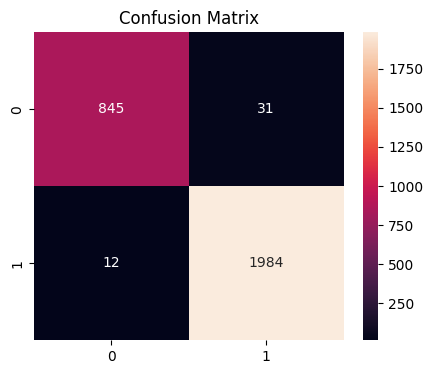

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

Model achieved good accuracy on test data and successfully classifies fake vs real news.

In [13]:
def predict_news(news):
    news = clean_text(news)
    vec = vectorizer.transform([news])
    pred = model.predict(vec)
    return "Fake News" if pred[0] == 1 else "Real News"

print(predict_news("Government announces new education policy"))

Fake News
